In [187]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,mean_squared_error, r2_score

In [188]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [189]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,NaN,NaN,120.666667,10.263203,NaN,NaN,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,NaN,NaN,127.333333,5.686241,NaN,NaN,NaN,NaN


In [190]:
train= df.iloc[:-12,:]
test= df.iloc[-12:,:]

In [191]:
train.shape

(106, 14)

In [192]:
train= train.asfreq('MS')

In [193]:
simple_model= SimpleExpSmoothing(train['#Passengers'].ffill()).fit()

In [194]:
simple_pred= simple_model.forecast(len(test))

In [195]:
simple_pred

1959-09-01    559.0
1959-10-01    559.0
1959-11-01    559.0
1959-12-01    559.0
1960-01-01    559.0
1960-02-01    559.0
1960-03-01    559.0
1960-04-01    559.0
1960-05-01    559.0
1960-06-01    559.0
1960-07-01    559.0
1960-08-01    559.0
Freq: MS, dtype: float64

In [200]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  train.plot(legend= True)
  test.plot(legend=True)
  predictions.plot(legend= True)

  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(mean_squared_error(test,predictions, squared=False), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

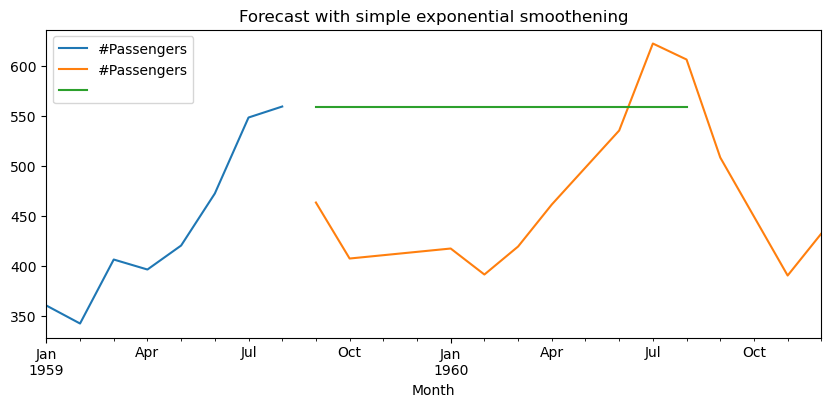

mean absolute error: 106.42
mean absolute percentage error: 25.0%
r2 score: -1.31
root mean squared error: 116.89


C:\ProgramData\new\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [202]:
model_evaluator(train.loc['1959']['#Passengers'],test['#Passengers'],simple_pred, 'simple exponential smoothening')